### Продолжаем повышать эффективность моделей и ансамбля! Кроме того, нужно больше метрик и тестирования.

In [73]:
from pathlib import Path
from random import seed
from sklearn.dummy import DummyClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import MultiLabelBinarizer, StandardScaler, RobustScaler
from sklearn.utils import class_weight
import collections
import pandas as pd
import torch

from importer import *

In [74]:
PATH_ACTIVITY = Path('../DATA/activity/')
PATH_METAINFO = Path('../DATA/metainfo/name+type+ghedonic+gender.csv')
PATH_SPECTRAL = Path('../DATA/spectral/')

### 1. Конвертируем данные EEG-Cutter в нужный формат

In [75]:
activity_df_columns = []

for i in range(2): # На каждое предъявление у нас 3 файла,
                   # 3-й мы будем вычитать из 1-го и из 2-го
    for zn in ZONE_NAMES:
        activity_df_columns.append(f'{zn}_{i+1}')

activity_df = pd.DataFrame(columns=activity_df_columns)
subjects = Path.iterdir(PATH_ACTIVITY)
iii = 0

for subject in sorted(subjects):
    if subject.is_dir():
        files = sorted(filter(lambda f: str(f).endswith('.csv'), Path.iterdir(subject)))
        print(subject, len(files))
        
        for i in range(0, len(files), 3):
            p0 = convert_eegc_activity(files[i])
            p10 = convert_eegc_activity(files[i+1])
            p100 = convert_eegc_activity(files[i+2])

            delta1 = {k: p0[k] - p100[k] for k in p0}
            delta2 = {k: p10[k] - p100[k] for k in p10}

            for k, v in delta1.items():
                activity_df.at[iii, f'{k}_1'] = v
            for k, v in delta2.items():
                activity_df.at[iii, f'{k}_2'] = v

            iii += 1

../DATA/activity/Bmet_001 72
../DATA/activity/Bmet_007 18
../DATA/activity/Bmet_011 21
../DATA/activity/Met_003 36
../DATA/activity/Met_004 36
../DATA/activity/Met_005 36
../DATA/activity/Met_006 36
../DATA/activity/Met_009 18
../DATA/activity/Met_010 30
../DATA/activity/Met_011 21
../DATA/activity/Met_013 18
../DATA/activity/NOTUSEDBYSHI 0


In [76]:
activity_df

,LF_1,MF_1,RF_1,LT_1,MC_1,RT_1,LP_1,MP_1,RP_1,LF_2,MF_2,RF_2,LT_2,MC_2,RT_2,LP_2,MP_2,RP_2
0,0.407766,0.004426,-0.003005,0.082742,-0.07042,-0.024272,0.11594,0.01524,0.083118,-0.249729,0.010985,-0.152518,-0.096465,-0.050107,-0.092899,0.10161,0.143787,-0.057852
1,0.127947,0.108755,0.017622,0.010425,0.043905,0.170563,-0.068743,-0.199585,-0.058262,0.23326,-0.124707,0.045846,0.021066,0.041013,-0.086686,-0.10246,0.014511,0.082752
2,0.035437,-0.068243,0.121052,0.02179,0.054783,-0.120041,0.044528,-0.273911,0.125953,-0.106089,-0.336216,-0.071849,-0.064039,0.169695,0.049142,-0.024852,-0.065088,-0.02176
3,0.420544,-0.395108,0.124535,0.073632,-0.030876,0.045107,-0.072702,-0.419326,0.039387,0.521661,-0.256036,0.395502,0.030065,-0.058379,0.066512,0.044916,-0.165503,-0.012589
4,0.426035,-0.090777,0.196875,0.113779,-0.132729,0.049885,0.011725,-0.156083,-0.007535,-0.388224,-0.058263,-0.124829,-0.165576,0.097775,-0.071409,-0.059249,-0.038213,-0.064399
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
109,0.088191,0.010942,0.022813,0.023624,0.032087,0.15901,0.145301,0.112881,0.317546,-0.104223,-0.009773,0.366493,0.131785,0.043586,-0.309942,0.271386,-0.025747,-0.089629
110,-0.480998,-0.308856,0.290684,0.332032,-0.028832,-0.230101,-0.058325,-0.033538,-0.10915,0.092222,-0.226209,0.168962,0.382058,-0.041152,0.652146,-0.138042,0.120163,-0.142922
111,-0.123498,-0.056899,0.172386,0.194827,0.053798,-0.449821,0.05717,-0.066195,0.025463,-0.073922,0.015785,0.103151,0.270246,-0.026154,-0.038716,0.10544,0.099473,0.460406
112,-0.220663,0.121912,-0.261202,0.107631,0.18335,-0.241005,0.609047,0.042978,-0.902252,-0.578094,0.006552,0.192032,0.483955,-0.031218,0.101183,0.237179,-0.043493,-0.020428


### 2. Подготавливаем метаданные и спектральные характеристики

Метаданные (в т.ч. категории запахов), в сочетании с активностями областей по sLORETA, используются в первом датасете, а спектральные характреистики (опять таки в сочетании с метаданными) нужны для второго.

In [77]:
metainfo = pd.read_csv(PATH_METAINFO)

counts = collections.Counter()

for t, c in metainfo['scent_type'].value_counts().items():
    ts = str(t).split('/')
    
    for s in ts:
        ss = s.strip()
        counts[ss] += c

type_c = pd.Series(counts)

type_c.sort_values()

Землистые       2
Мятные          7
Гурманские     15
Травянистые    15
Древесные      17
Хвойные        20
Цветочные      23
Цитрусовые     29
dtype: int64

In [78]:
metainfo['scent_type_split'] = metainfo['scent_type'].apply(
    lambda ts: [t.strip() for t in ts.split('/')]
)

mlb = MultiLabelBinarizer()
groups = mlb.fit_transform(metainfo['scent_type_split'])

groups_df = pd.DataFrame(groups, columns=mlb.classes_)

groups_df

,Гурманские,Древесные,Землистые,Мятные,Травянистые,Хвойные,Цветочные,Цитрусовые
0,0,1,0,0,0,0,0,0
1,0,0,0,0,0,1,0,0
2,0,0,0,0,0,1,0,0
3,0,0,0,0,0,0,1,0
4,1,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...
109,0,0,0,0,0,0,0,1
110,0,0,0,0,0,0,1,0
111,0,0,0,0,0,0,0,1
112,0,0,0,0,0,0,1,0


In [79]:
spectral_df_columns = []

for rhythm in ('δ', 'θ', 'α', 'β', 'γ'):
    # Да, именно в таком порядке!
    # См. https://ru.wikipedia.org/wiki/Ритмы_головного_мозга
    for zn in ZONE_NAMES:
        spectral_df_columns.append(f'{rhythm}_{zn}')

spectral_df = pd.DataFrame(columns=spectral_df_columns).astype('float32')

subjects = Path.iterdir(PATH_SPECTRAL)

for i, r in enumerate(('delta', 'theta', 'alpha', 'beta', 'gamma')):
    spectre = pd.read_csv(PATH_SPECTRAL / (r + '.csv'))

    spectral_df.iloc[:, i*9 : i*9+9] = spectre.iloc[:, 2:11].values

spectral_df

/tmp/ipykernel_229562/4124933630.py:16: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[1.05267017e+03 1.02860034e+03 6.19647461e+02 1.66636145e+03
 1.11820471e+03 5.34555359e+02 8.12467163e+02 7.66041687e+02
 1.63260620e+03 1.00733319e+03 2.06729443e+03 8.19500854e+02
 2.38282090e+04 1.66173344e+05 1.93805188e+05 1.09007086e+05
 3.09718125e+05 2.28121531e+05 1.97585516e+05 3.01948875e+05
 6.60149438e+05 1.03637556e+06 1.00429883e+05 2.37805938e+04
 7.68161774e+01 8.00840530e+01 5.30507355e+01 7.72419052e+01
 5.39906349e+01 6.45988312e+01 3.42844696e+01 2.61776524e+01
 2.78865910e+01 2.71302700e+01 3.28275757e+01 2.98802700e+01
 3.37602043e+01 1.09623756e+02 5.55230751e+01 1.26869408e+02
 8.25429077e+01 7.11396256e+01 6.25417328e+01 9.22183533e+01
 7.25955582e+01 1.18197975e+02 9.15843658e+01 5.77279739e+01
 4.21325500e+02 2.81964050e+02 1.37455612e+02 1.90302155e+02
 1.30559708e+02 9.46272888e+01 2.66327229e+01 2.8

,δ_LF,δ_MF,δ_RF,δ_LT,δ_MC,δ_RT,δ_LP,δ_MP,δ_RP,θ_LF,...,β_RP,γ_LF,γ_MF,γ_RF,γ_LT,γ_MC,γ_RT,γ_LP,γ_MP,γ_RP
0,394.282043,1052.670166,340.846619,417.891632,624.345215,356.835876,847.289734,544.589966,817.558960,59.074821,...,37.029888,199.981049,71.096779,32.656998,64.772011,1200.609009,52.518333,961.223938,958.408447,1641.589722
1,762.995667,1028.600342,323.704681,523.671509,3088.326904,236.548523,3412.561523,2571.625977,4525.356934,80.203697,...,93.544815,220.646896,78.612442,32.818657,75.055435,1240.861206,62.599491,1048.204224,1000.914795,1702.527710
2,624.088623,619.647461,214.890778,362.819153,2063.662842,282.017670,2571.751465,2155.573486,2894.437012,51.422115,...,78.263687,277.299713,98.526665,36.027576,97.729782,1324.911621,68.919403,1248.845947,1095.593994,1826.238159
3,1850.210327,1666.361450,584.639832,965.549133,5260.854980,560.366577,7790.125000,5372.615723,8168.583008,149.589188,...,160.597122,501.910645,176.329025,54.761299,202.971405,2008.698364,63.239769,2481.108643,1757.602661,2808.519043
4,1587.042114,1118.204712,321.446777,684.041443,4352.611328,409.999542,4622.062988,3480.548584,6394.530762,151.863632,...,170.729218,522.595520,182.873444,52.384823,259.869598,1875.250000,72.528259,2702.287109,1709.924683,2638.802734
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
109,52.529495,32.003029,57.564640,79.792259,26.361336,282.841888,27.592903,21.467812,75.760773,21.167177,...,20.194298,19.207043,9.158166,14.601722,30.616104,4.883770,12.496562,6.511979,5.536946,14.388382
110,52.660519,37.597427,64.193718,77.507248,32.133537,119.770058,36.273335,21.740889,58.752228,25.902210,...,20.669523,15.640918,6.016054,11.199177,16.251923,4.368326,16.239906,5.572407,4.487237,13.464450
111,48.808262,34.186184,48.719093,52.038326,22.092644,51.083508,24.270288,17.192556,48.512646,21.284058,...,21.487478,23.787455,9.715988,13.419046,23.677118,5.281605,14.337770,7.586077,5.050881,15.914467
112,53.893646,32.969524,88.254791,61.386993,28.986883,49.418941,35.856918,28.828800,56.903214,20.861874,...,29.863012,28.553324,14.476421,20.893141,66.449112,7.059452,19.008575,9.604828,6.554445,22.771816


**Последняя проверка, что ничего не поехало по одному месту:**

In [80]:
print(
    metainfo.shape[1],    # = 2 + 2 + 1 + 1 + 1
    groups_df.shape[1],   # = От 8 до 10
    activity_df.shape[1], # = CSV_PER_CAT * 9
    spectral_df.shape[1]  # = 5 * 9
)

assert(metainfo.shape[0] == groups_df.shape[0] == activity_df.shape[0] == spectral_df.shape[0])

7 8 18 45


### 3. Агрегируем датасеты для обоих версий модели

**ДАТАСЕТ 1:** гендер + encode категории(-й) + средняя активность областей на sLORETA --> гедоническая оценка

**ДАТАСЕТ 2:** гендер + encode категории(-й) + спектральные характеристики областей --> гедоническая оценка

In [ ]:
dataset_input1 = pd.concat([
    metainfo['gender'],
    groups_df,
    activity_df
], axis=1).astype('float32')

dataset_input2 = pd.concat([
    metainfo['gender'],
    groups_df,
    spectral_df
], axis=1).astype('float32')

dataset_output = pd.concat([
    # metainfo['gender'],
    metainfo['ghedonic'].apply(lambda g: (g + 3.0) / 5.0) # (g + 2.0) / 4.0)
]).astype('float32')

dataset_output

0      0.8
1      0.4
2      0.8
3      0.4
4      0.2
      ... 
109    0.8
110    0.6
111    1.0
112    0.8
113    0.4
Name: ghedonic, Length: 114, dtype: float32

In [82]:
RANDOM_SEED = 80085

def init_seed():
    torch.manual_seed(RANDOM_SEED)
    torch.cuda.manual_seed(RANDOM_SEED)
    torch.cuda.manual_seed_all(RANDOM_SEED)
    np.random.seed(RANDOM_SEED)
    seed(RANDOM_SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

init_seed()

Главная бЯда нашего датасета -- в нём много выбросов! Вся моя бессонная ночь была посвящена изучению его проблем, и именно эта оказалось главной, т.к. из-за неё случались жёсткие взлёты loss на test. Так исправим же это, хотя бы отчасти:

In [83]:
def scale_with_clip(train_dataset, test_dataset):
    train_cat = train_dataset.iloc[:, :-len(activity_df_columns)]
    train_eeg = train_dataset.iloc[:, -len(activity_df_columns):]
    test_cat = test_dataset.iloc[:, :-len(activity_df_columns)]
    test_eeg = test_dataset.iloc[:, -len(activity_df_columns):]

    l, h = np.percentile(train_eeg, [5, 95]) # [10, 90] ???
    train_eeg = np.clip(train_eeg, l, h)
    test_eeg = np.clip(test_eeg, l, h)

    scaler = RobustScaler() # Согл. методу тыка, StandardScaler работает хуже
    train_eeg = scaler.fit_transform(train_eeg)
    test_eeg = scaler.transform(test_eeg)

    return (
        np.concatenate([train_cat.values, train_eeg], axis=1),
        np.concatenate([test_cat.values, test_eeg], axis=1)
    )


def scale_without_clip(train_dataset, test_dataset):
    scaler = StandardScaler() # RobustScaler портит спектральные хар-ки
    new_train_dataset = scaler.fit_transform(train_dataset)
    new_test_dataset = scaler.transform(test_dataset)

    return new_train_dataset, new_test_dataset

In [84]:
train_input1, test_input1, train_output, test_output = train_test_split(
    dataset_input1, dataset_output, test_size=0.3, random_state=RANDOM_SEED
)
train_input1, test_input1 = scale_with_clip(train_input1, test_input1)


train_input2, test_input2, _, _ = train_test_split(
    dataset_input2, dataset_output, test_size=0.3, random_state=RANDOM_SEED
)
train_input2, test_input2 = scale_without_clip(train_input2, test_input2)

In [85]:
print(f'Данных в train: {len(train_input1)}, Данных в test: {len(test_input1)}')

Данных в train: 79, Данных в test: 35


In [86]:
dataset_output.value_counts()

ghedonic
0.8    40
0.6    28
1.0    24
0.4    14
0.2     8
Name: count, dtype: int64

### 4. Задаём архитектуру моделей и пайплайн обучения

<!-- Архитектура примерно такая же, как и в прошылй раз, покрмр на текущий момент -->

Из-за дисбаланса классов (показан выше), у нас модель становится заметно biased в сторону позитивных оценок. Поэтому нужно применить взвешивание лосса, чтобы "наказывать" модель больше за ошибки на более маленьких классах.

In [87]:
classes = (dataset_output.values * 5 - 3).astype(int)

classes

array([ 1, -1,  1, -1, -2, -2,  1,  2, -1,  0,  0,  1,  2,  2, -2,  0, -2,
        1,  1, -2,  2, -2, -2,  1,  0,  0,  2,  0, -2,  2,  0,  0,  2, -1,
        0,  1, -1,  1, -1,  1,  0,  0,  1,  1,  1,  2,  1, -1,  2,  2,  0,
        0, -1,  0,  1, -1,  1,  2,  1,  1,  1,  1,  0,  1,  1, -1,  1,  2,
        0,  1,  2,  1, -1,  1,  0,  1,  0,  2,  0,  0,  0,  0,  1,  0,  0,
        1,  1,  1,  1,  2,  2,  1,  2,  2, -1,  0,  1,  2,  2,  0, -1,  1,
        0,  1,  1,  2,  1,  2,  2,  1,  0,  2,  1, -1])

In [88]:
class_weights = class_weight.compute_class_weight(
    'balanced', classes=np.unique(classes), y=classes
)

class_weights

array([2.85      , 1.62857143, 0.81428571, 0.57      , 0.95      ])

In [89]:
def learning_pipeline(
        model,
        train_input,
        train_output,
        test_input,
        test_output,
        class_weights=None,
        comments=True
    ):
    train_input_t = torch.tensor(train_input, dtype=torch.float32)
    train_output_t = torch.tensor(train_output.values, dtype=torch.float32).unsqueeze(1)
    test_input_t = torch.tensor(test_input, dtype=torch.float32)
    test_output_t = torch.tensor(test_output.values, dtype=torch.float32).unsqueeze(1)

    criterion = torch.nn.MSELoss(
        reduction='none' if class_weights is not None else 'mean'
    )
    optimizer = torch.optim.Adam(model.parameters(), lr=0.00002, weight_decay=0.001)


    best_pred = None
    best_loss = 99.99
    best_e = -1

    for e in range(100000):
        model.train()
        optimizer.zero_grad()

        train_pred = model(train_input_t)

        if class_weights is not None:
            train_classes = (train_output_t.squeeze() * 4).int() # bruh
            train_weights = torch.tensor(
                [class_weights[c.item()] for c in train_classes],
            dtype=torch.float32)
            loss_per_sample = criterion(train_pred, train_output_t).squeeze()

            train_loss = (loss_per_sample * train_weights).mean()
        
        else:
            train_loss = criterion(train_pred, train_output_t)

        train_loss.backward()
        optimizer.step()

        model.eval()
        with torch.no_grad():
            test_pred = model(test_input_t)
            test_loss = criterion(test_pred, test_output_t).mean()

            if test_loss.item() < best_loss:
                best_e = e
                best_loss = test_loss.item()
                best_pred = test_pred.clone()

        if e % 200 == 0:
            if comments:
                print(f'Потери на train на эпохе {e} = {train_loss.item()}')
                print(f'Потери на test на эпохе {e} = {test_loss.item()}\n')

            if e - best_e >= 2000:
                if comments:
                    print('Модель перестала учиться, this is the end...')

                print(f'Лучшая эпоха: {best_e} (потери на test: {best_loss})')
                break
    
    return (
        test_output_t.squeeze().numpy(),
        best_pred.squeeze().numpy(),
        best_loss
    )

Что интересно, в прошлый раз наличие сигмоиды для результатов повышало loss! Моя теория была в том, что её наличие ухудшает bias для "крайних" результатов, однако, по-видимому, виновником этому в старой структуре было нечто другое.

P.s. Что такое SiLU (штука довольно новая), см. здесь: https://docs.pytorch.org/docs/stable/generated/torch.nn.SiLU.html

In [90]:
DROPOUT_P = 0.1


class Dataset1Model(torch.nn.Module):
    def __init__(self):
        super(Dataset1Model, self).__init__()

        self.fc1 = torch.nn.Linear(27, 12)     # = Гендер (1) + Категории (8) + Активности областей (9*2)
        self.do1 = torch.nn.Dropout(DROPOUT_P) # Контрим переобучение на малом кол-ве данных
        self.fc2 = torch.nn.Linear(12, 6)      # Расширяем
        self.do2 = torch.nn.Dropout(DROPOUT_P) # Контрим переобучение на малом кол-ве данных
        self.out = torch.nn.Linear(6, 1)       # = Гедоническая оценка (1)

    def forward(self, x):
        x = torch.nn.functional.silu(self.fc1(x))
        x = self.do1(x)
        x = torch.nn.functional.silu(self.fc2(x))
        x = self.do2(x)
        x = self.out(x)

        return torch.sigmoid(x) # torch.clamp(x, 0.0, 1.0)

class Dataset2Model(torch.nn.Module):
    def __init__(self):
        super(Dataset2Model, self).__init__()

        self.fc1 = torch.nn.Linear(54, 16)     # = Гендер (1) + Категории (8) + Спектральные хар-ки (9*5)
        self.do1 = torch.nn.Dropout(DROPOUT_P) # Контрим переобучение на малом кол-ве данных
        self.fc2 = torch.nn.Linear(16, 8)      # Расширяем
        self.do2 = torch.nn.Dropout(DROPOUT_P) # Контрим переобучение на малом кол-ве данных
        self.out = torch.nn.Linear(8, 1)       # = Гедоническая оценка (1)

    def forward(self, x):
        x = torch.nn.functional.silu(self.fc1(x))
        x = self.do1(x)
        x = torch.nn.functional.silu(self.fc2(x))
        x = self.do2(x)
        x = self.out(x)

        return torch.sigmoid(x) # torch.clamp(x, 0.0, 1.0)

In [91]:
init_seed()

# БЕЗ ВЗВЕШИВАНИЯ КЛАССОВ
test_real1, test_pred1, _ = learning_pipeline(
    Dataset1Model(),
    train_input1,
    train_output,
    test_input1,
    test_output,
    None,
    comments=False
)

Лучшая эпоха: 4260 (потери на test: 0.054714083671569824)


In [92]:
init_seed()

# СО ВЗВЕШИВАНИЕМ КЛАССОВ
test_real2, test_pred2, _ = learning_pipeline(
    Dataset1Model(),
    train_input1,
    train_output,
    test_input1,
    test_output,
    class_weights,
    comments=False
)

Лучшая эпоха: 4163 (потери на test: 0.05869253724813461)


Казалось бы, после взвешивания стало даже хуже? А вот нифига, просто MSE нам это не покажет! Проверить это можно будет в дальнейшем по матрицам ошибок.



### 5. Создаём ансамбль из двух моделей

Практичность и эффективность сборки ансамблей из двух этих датасетов была доказана в прошлой работе.

In [93]:
# Меньше 10 разбиений KFold практически не имеет смысла!
ss = 20 # Для быстрого прогона 10, для полной картины 20
si = 1
kf = KFold(n_splits=ss, shuffle=True, random_state=RANDOM_SEED)


res_real = []
res_pred1 = []
res_loss1 = []
res_pred2 = []
res_loss2 = []

for train_idx, test_idx in kf.split(dataset_input1):
    kf_input1_train, kf_input1_test = dataset_input1.iloc[train_idx], dataset_input1.iloc[test_idx]
    kf_input2_train, kf_input2_test = dataset_input2.iloc[train_idx], dataset_input2.iloc[test_idx]
    kf_output_train, kf_output_test = dataset_output.iloc[train_idx], dataset_output.iloc[test_idx]

    kf_input1_train, kf_input1_test = scale_with_clip(kf_input1_train, kf_input1_test)
    kf_input2_train, kf_input2_test = scale_without_clip(kf_input2_train, kf_input2_test)

    print(f'\n=== Разбиение {si} из {ss} ===')

    init_seed()
    real, pred, loss = learning_pipeline(
        Dataset1Model(),
        kf_input1_train,
        kf_output_train,
        kf_input1_test,
        kf_output_test,
        class_weights,
        comments=False
    )
    res_pred1.append(pred)
    res_loss1.append(loss)

    init_seed()
    _, pred, loss = learning_pipeline(
        Dataset2Model(),
        kf_input2_train,
        kf_output_train,
        kf_input2_test,
        kf_output_test,
        class_weights,
        comments=False
    )
    res_pred2.append(pred)
    res_loss2.append(loss)

    res_real.append(real)
    si += 1


print('')
print(f'Пространств. х-ки -- Avg {np.mean(res_loss1)}, Std {np.std(res_loss1)}')
print(f'Спектральные х-ки -- Avg {np.mean(res_loss2)}, Std {np.std(res_loss2)}')


=== Разбиение 1 из 20 ===
Лучшая эпоха: 2675 (потери на test: 0.02593042142689228)
Лучшая эпоха: 238 (потери на test: 0.02427816390991211)

=== Разбиение 2 из 20 ===
Лучшая эпоха: 3842 (потери на test: 0.06699720770120621)
Лучшая эпоха: 0 (потери на test: 0.10190829634666443)

=== Разбиение 3 из 20 ===
Лучшая эпоха: 2346 (потери на test: 0.06091180443763733)
Лучшая эпоха: 2616 (потери на test: 0.052228864282369614)

=== Разбиение 4 из 20 ===
Лучшая эпоха: 3186 (потери на test: 0.11842649430036545)
Лучшая эпоха: 2340 (потери на test: 0.10218163579702377)

=== Разбиение 5 из 20 ===
Лучшая эпоха: 15838 (потери на test: 0.02776666171848774)
Лучшая эпоха: 8093 (потери на test: 0.04300839081406593)

=== Разбиение 6 из 20 ===
Лучшая эпоха: 5515 (потери на test: 0.007184809539467096)
Лучшая эпоха: 0 (потери на test: 0.009654104709625244)

=== Разбиение 7 из 20 ===
Лучшая эпоха: 10901 (потери на test: 0.03894977271556854)
Лучшая эпоха: 6995 (потери на test: 0.05391825735569)

=== Разбиение 8 и

In [94]:
y = np.concatenate(res_real)
p1 = np.concatenate(res_pred1)
p2 = np.concatenate(res_pred2)

# Матрица совпадения ошибок
print(np.corrcoef(y - p1, y - p2))

mse_1 = np.mean((y - p1) ** 2)
mse_2 = np.mean((y - p2) ** 2)
mse_1and2 = np.mean((y - (p1 + p2) / 2) ** 2)

[[1.         0.82085179]
 [0.82085179 1.        ]]


Чем БОЛЬШЕ числа не-диагональных элементов матрицы, тем лучше "покрывают" друг друга обученные модели.

Теперь посчитаем оптимальный коэффициент для взвешенного голосования (в идеале д.б. что-то в районе 60 / 40):

In [95]:
best_w = 0.0
best_mse = float('inf')

for w in np.linspace(0, 1, 101):
    pred = w * p1 + (1 - w) * p2
    mse = np.mean((y - pred) ** 2)
    
    if mse < best_mse:
        best_mse = mse
        best_w = w

print(f'Лучшие веса ансамбля: {best_w:.2f} / {1 - best_w:.2f}')


# Метрика по каждой модели и их ансамблю
print(f'\nMSE простр.: {mse_1} \nMSE спектр.: {mse_2} \nMSE анс-бля: {best_mse}')

Лучшие веса ансамбля: 0.70 / 0.30

MSE простр.: 0.04909138008952141 
MSE спектр.: 0.05558176338672638 
MSE анс-бля: 0.04756456285592617


<!-- ### ДО ВЗВЕШИВАНИЯ:

```
[[1.         0.85467097]
 [0.85467097 1.        ]]

Лучшие веса ансамбля: 0.82 / 0.18

MSE простр.: 0.048033442348241806 
MSE спектр.: 0.05798713490366936 
MSE ансамбля: 0.047520677357869794
``` -->

### 6. Метрики и визуализации

***Всё плохо.***

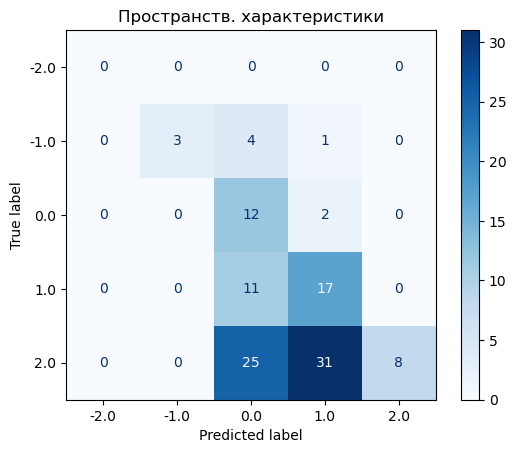

              precision    recall  f1-score   support

        -2.0       0.00      0.00      0.00         0
        -1.0       1.00      0.38      0.55         8
         0.0       0.23      0.86      0.36        14
         1.0       0.33      0.61      0.43        28
         2.0       1.00      0.12      0.22        64

    accuracy                           0.35       114
   macro avg       0.51      0.39      0.31       114
weighted avg       0.74      0.35      0.31       114



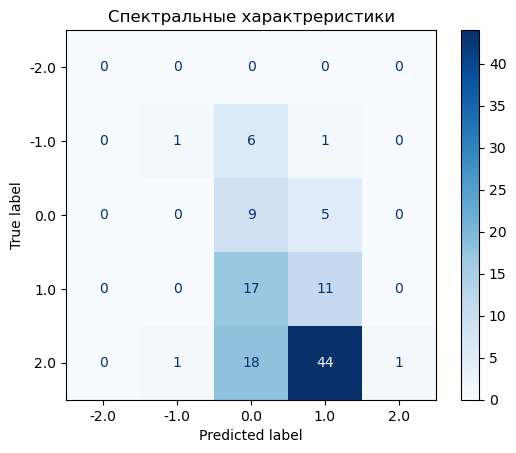

              precision    recall  f1-score   support

        -2.0       0.00      0.00      0.00         0
        -1.0       0.50      0.12      0.20         8
         0.0       0.18      0.64      0.28        14
         1.0       0.18      0.39      0.25        28
         2.0       1.00      0.02      0.03        64

    accuracy                           0.19       114
   macro avg       0.37      0.24      0.15       114
weighted avg       0.66      0.19      0.13       114



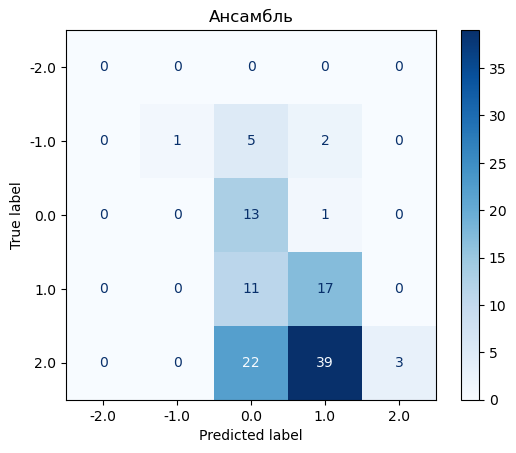

              precision    recall  f1-score   support

        -2.0       0.00      0.00      0.00         0
        -1.0       1.00      0.12      0.22         8
         0.0       0.25      0.93      0.40        14
         1.0       0.29      0.61      0.39        28
         2.0       1.00      0.05      0.09        64

    accuracy                           0.30       114
   macro avg       0.51      0.34      0.22       114
weighted avg       0.73      0.30      0.21       114



In [ ]:
def confusion_and_report(y_true, y_pred, label=''):
    boundaries = np.linspace(0, 1, 6)[1:-1] # 6, 10, 18...
    y_cls = np.digitize(y_true, boundaries)
    p_cls = np.digitize(y_pred, boundaries)

    display_labels = np.linspace(-2.0, +2.0, len(boundaries) + 1)

    cm = confusion_matrix(y_cls, p_cls, labels=np.arange(len(boundaries) + 1))

    disp = ConfusionMatrixDisplay(cm, display_labels=display_labels)
    disp.plot(cmap='Blues', values_format='d')
    plt.title(label)
    plt.show()

    print(
        classification_report(
            y_cls,
            p_cls,
            labels=np.arange(len(display_labels)),
            target_names=display_labels.astype(str),
            zero_division=0
        )
    )


confusion_and_report(y, p1, 'Пространств. характеристики')
confusion_and_report(y, p2, 'Спектральные характреристики')
confusion_and_report(y, (best_w * p1 + (1-best_w) * p2), 'Ансамбль')

Для сравнения, "тупая" модель (предсказывает самый яастый класс):

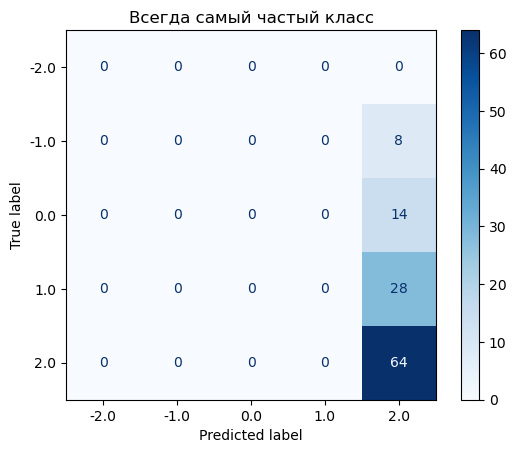

              precision    recall  f1-score   support

        -2.0       0.00      0.00      0.00         0
        -1.0       0.00      0.00      0.00         8
         0.0       0.00      0.00      0.00        14
         1.0       0.00      0.00      0.00        28
         2.0       0.56      1.00      0.72        64

    accuracy                           0.56       114
   macro avg       0.11      0.20      0.14       114
weighted avg       0.32      0.56      0.40       114



In [ ]:
edges = np.linspace(0, 1, 6)
y_cls = np.digitize(y, edges[1:-1])

dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(y_cls.reshape(-1,1), y_cls)
p3 = dummy.predict(y_cls.reshape(-1,1))

confusion_and_report(y, p3, 'Всегда самый частый класс')

Полный список предсказаний:

_(в нашем случае именно это, по идее, будет выступать одной из самых важных метрик, поскольку при отклонении <20% категория всё ещё будет определяться корректно, а при отклонении выше 40% ни о какой точности речи уже не идёт)_

In [102]:
errors = np.abs(y - (best_w * p1 + (1 - best_w) * p2))

idx = np.argsort(errors)
for i in idx:
    print(
        f'№ {i}\t| Реальн.: {y[i]:.2f}\t'
        + f'| Предск.: {(best_w * p1 + (1 - best_w) * p2)[i]:.8f}\t'
        + f'| Ошибка: {'🔴' if errors[i] > 0.4 else '⭕' if errors[i] > 0.2 else '🟢'} {errors[i]}'
    )

print(f'\nКол-во 🔴+⭕: {len(errors[errors > 0.2])} / {len(errors)}')
print(f'🔥 Итог: {len(errors[errors <= 0.2]) / len(errors) * 100} %')

print(f'Кол-во 🔴: {len(errors[errors > 0.4])} / {len(errors)}')
print(f'🔥 Итог: {len(errors[errors <= 0.4]) / len(errors) * 100} %')

№ 34	| Реальн.: 0.60	| Предск.: 0.60015475	| Ошибка: 🟢 0.00015472769737245873
№ 97	| Реальн.: 0.60	| Предск.: 0.60117673	| Ошибка: 🟢 0.0011767089366911954
№ 51	| Реальн.: 0.60	| Предск.: 0.60119030	| Ошибка: 🟢 0.0011902809143066184
№ 31	| Реальн.: 0.60	| Предск.: 0.59455214	| Ошибка: 🟢 0.00544788241386418
№ 27	| Реальн.: 0.80	| Предск.: 0.81057491	| Ошибка: 🟢 0.010574901103973411
№ 57	| Реальн.: 0.60	| Предск.: 0.58919302	| Ошибка: 🟢 0.010807001590728671
№ 41	| Реальн.: 0.60	| Предск.: 0.61468167	| Ошибка: 🟢 0.014681643247604348
№ 103	| Реальн.: 0.60	| Предск.: 0.61490068	| Ошибка: 🟢 0.014900660514831632
№ 2	| Реальн.: 0.60	| Предск.: 0.58501754	| Ошибка: 🟢 0.014982485771179221
№ 35	| Реальн.: 0.60	| Предск.: 0.62537403	| Ошибка: 🟢 0.02537400126457212
№ 98	| Реальн.: 0.80	| Предск.: 0.77121108	| Ошибка: 🟢 0.028788930177688576
№ 3	| Реальн.: 0.60	| Предск.: 0.56948910	| Ошибка: 🟢 0.030510920286178633
№ 63	| Реальн.: 0.60	| Предск.: 0.56916634	| Ошибка: 🟢 0.03083368539810183
№ 1	| Реальн